In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("customer_data.csv")

In [3]:
df.head()

,Age,Income,Spending_Score
0,56,54081.631580,6
1,69,81987.547764,35
2,46,NaN,38
3,32,82267.210119,35
4,60,60702.533399,74


In [4]:
df.shape

(5500, 3)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             5500 non-null   int64  
 1   Income          5350 non-null   float64
 2   Spending_Score  5500 non-null   int64  
dtypes: float64(1), int64(2)
memory usage: 129.0 KB


In [6]:
df.isnull().sum()

Age                 0
Income            150
Spending_Score      0
dtype: int64

In [7]:
df["Income"].fillna(df["Income"].median(), inplace=True)

C:\Users\merog\AppData\Local\Temp\ipykernel_31488\2383243780.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Income"].fillna(df["Income"].median(), inplace=True)


In [8]:
df.isnull().sum()

Age               0
Income            0
Spending_Score    0
dtype: int64

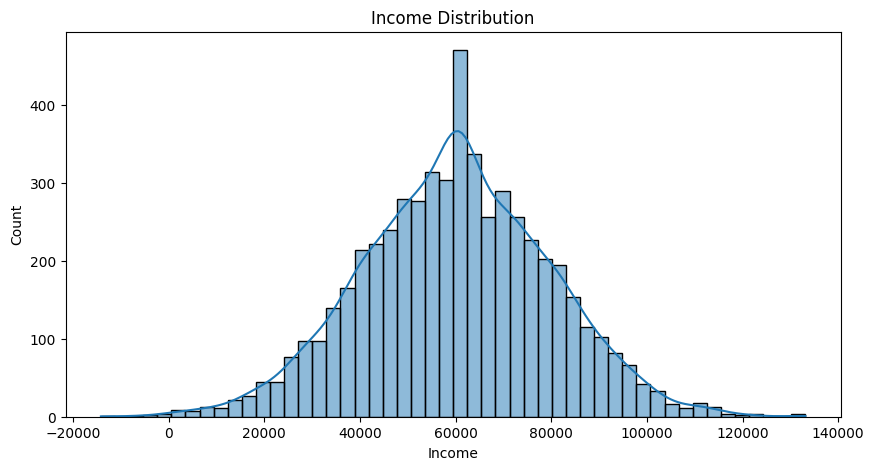

In [9]:
plt.figure(figsize=(10,5))

sns.histplot(df["Income"], kde=True)

plt.title("Income Distribution")

plt.show()

In [10]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

In [11]:
wcss = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

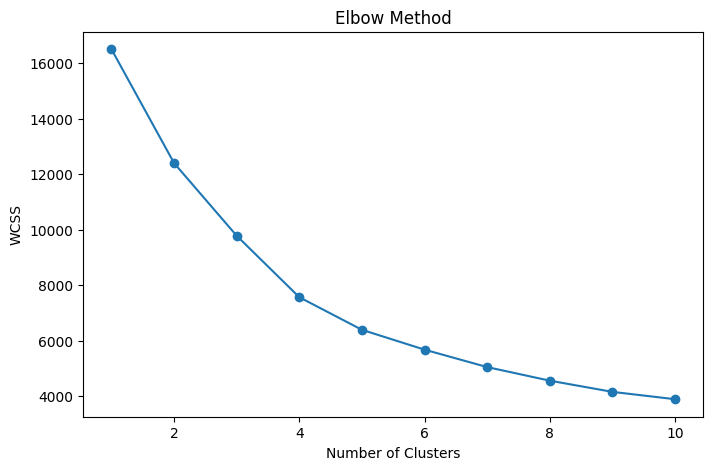

In [12]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [13]:
scores = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    scores.append(score)

    print(f"k = {k} --> Silhouette Score = {score:.4f}")

k = 2 --> Silhouette Score = 0.2753
k = 3 --> Silhouette Score = 0.2869
k = 4 --> Silhouette Score = 0.2730
k = 5 --> Silhouette Score = 0.2429
k = 6 --> Silhouette Score = 0.2529
k = 7 --> Silhouette Score = 0.2536
k = 8 --> Silhouette Score = 0.2507
k = 9 --> Silhouette Score = 0.2512
k = 10 --> Silhouette Score = 0.2511


In [14]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

In [15]:
df.head()

,Age,Income,Spending_Score,Cluster
0,56,54081.631580,6,1
1,69,81987.547764,35,1
2,46,60127.949617,38,1
3,32,82267.210119,35,0
4,60,60702.533399,74,1


In [16]:
score = silhouette_score(X_scaled, clusters)

print("Silhouette Score :", score)

Silhouette Score : 0.28685701982157924


In [17]:
df["Cluster"].value_counts()

Cluster
1    2736
0    2714
2      50
Name: count, dtype: int64

In [18]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)

In [19]:
pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = clusters

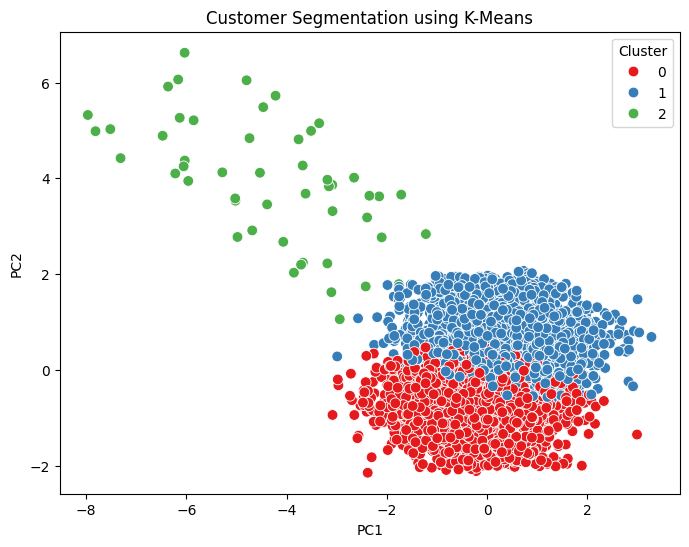

In [20]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    s=60
)

plt.title("Customer Segmentation using K-Means")

plt.show()